# BEAVERS: Climate Indices
***

**_Author:_** Chus Casado Rodríguez<br>
**_Date:_** 10-09-2026<br>

**Introduction:**<br>
This notebook creates the climate indices (static attributes) related to the meteorological time series. It produces as many CSV files as observational gridded datasets.

> <small>**Note**. This notebook is exactely the same as `'./notebooks/CAMELS/camels_3_attributes_meteo.ipynb'`, simply pointing to a different configuration file and outlets shapefile.</small>

In [1]:
import pandas as pd
import geopandas as gpd
import xarray as xr
from tqdm.auto import tqdm

from reservoirs_lshm.utils.plots import plot_attributes
from reservoirs_lshm.utils.utils import duration_precip_indices

from ocab.config import Config
import ocab.variables as VARS
import ocab.meteorology as METEO

## Configuration

In [2]:
cfg = Config('config_BEAVERS_v100.yml')
basin_id_field = 'gauge_id'

# path where the meteo time series were extracted
path_meteo = cfg.path_dataset / 'preprocessing' / 'timeseries' / 'meteo'

# save plots in folder
path_plots = cfg.path_plots / 'attributes'
path_plots.mkdir(parents=False, exist_ok=True)

print(f'Attribute tables will be saved in {cfg.path_attributes}')
print(f'Plots will be saved in {path_plots}')

Attribute tables will be saved in /home/casadoj/Data/BEAVERS-ES/v1_0_0/attributes
Plots will be saved in /home/casadoj/Data/BEAVERS-ES/v1_0_0/plots/attributes


## Data

### Basin outlets

In [3]:
# load basin outlets
outlets = gpd.read_file(cfg.path_gis / 'dams.geojson').set_index('id')
print(f'{len(outlets)} basin outlets')

366 basin outlets


### Meteorology

In [4]:
# load meteo time series
meteo = {}
for dataset, label in tqdm(METEO.DATASETS.items(), desc='Datasets'):
    meteo_i = []
    for ID in tqdm(outlets.index, desc='Stations', leave=False):
        # read time series
        df = pd.read_parquet(path_meteo / dataset / f'{ID}.parquet').loc[ID]

        # rename columns
        df.rename(columns=VARS.RENAME, inplace=True)
        
        # keep only average values
        df = df[['precip_mm', 'temp_degC', 'pet_mm']]
        
        # remove units from col names
        df.columns = [col.split('_')[0] for col in df.columns]
    
        # convert to xarray.Dataset and save
        ds = xr.Dataset.from_dataframe(df)
        ds = ds.assign_coords(id=ID).expand_dims('id')
        meteo_i.append(ds)

    # concat as dataset
    meteo_i = xr.concat(meteo_i, dim='id', join='outer')
    if dataset in METEO.OFFSET_HOURS:
        meteo_i['time'] = meteo_i['time'] + pd.Timedelta(hours=METEO.OFFSET_HOURS[dataset])

    # compute precipitation as snowfall
    meteo_i['snow'] = meteo_i['precip'].where(meteo_i['temp'] < 0, 0)

    # save
    meteo[label] = meteo_i

Datasets:   0%|          | 0/3 [00:00<?, ?it/s]

Stations:   0%|          | 0/366 [00:00<?, ?it/s]

Stations:   0%|          | 0/366 [00:00<?, ?it/s]

Stations:   0%|          | 0/366 [00:00<?, ?it/s]

## Attributes

### Compute

In [5]:
# average of all meteo variables
attributes = {}
for label, ds in tqdm(meteo.items()):

    # trim to study period
    start = pd.to_datetime(max(cfg.start, ds.time.data[0]))
    end = pd.to_datetime(min(cfg.end, ds.time.data[-1]))
    ds = ds.sel(time=slice(start, end))
    print(f'{label.upper():<10}:\t{start}\t{end}')
    
    # compute means
    attrs = ds.mean('time').to_dataframe()
    attrs.columns = [f'{col}_mean' for col in attrs.columns]
    attrs.index.name = outlets.index.name

    # indices
    attrs['aridity'] = attrs.precip_mean / attrs.pet_mean
    attrs['frac_snow'] = attrs.snow_mean / attrs.precip_mean
    attrs['moisture_index'] = attrs.precip_mean - attrs.pet_mean
    precip_monthly = ds['precip'].resample({'time': 'MS'}).sum().groupby('time.month').mean()
    precip_annual = ds['precip'].resample({'time': 'YS'}).sum().mean('time')
    attrs['seasonality'] = ((precip_monthly.max('month') - precip_monthly.min('month')) / precip_annual).to_pandas()

    # high and dry precipitation indices
    precip_extremes = {
        'high': 20, # mm
        'low': 1 # mm
    }
    for key, value in precip_extremes.items():
        if key == 'high':
            mask_precip = ds['precip'] > value
        elif key == 'low':
            mask_precip = ds['precip'] < value
        attrs[f'{key}_precip_freq'] = mask_precip.sum('time') / len(ds.time)
        attrs[f'{key}_precip_dur'] = duration_precip_indices(mask_precip.to_pandas().transpose())

    # add source to columns and save
    attrs.columns = [f'{col}_{label}' for col in attrs.columns]
    attributes[label] = attrs

  0%|          | 0/3 [00:00<?, ?it/s]

ROCIO     :	1980-10-01 00:00:00	2023-01-01 00:00:00
CERRA     :	1984-09-01 00:00:00	2025-09-30 00:00:00
EMO       :	1990-01-03 00:00:00	2023-01-02 00:00:00


### Plot

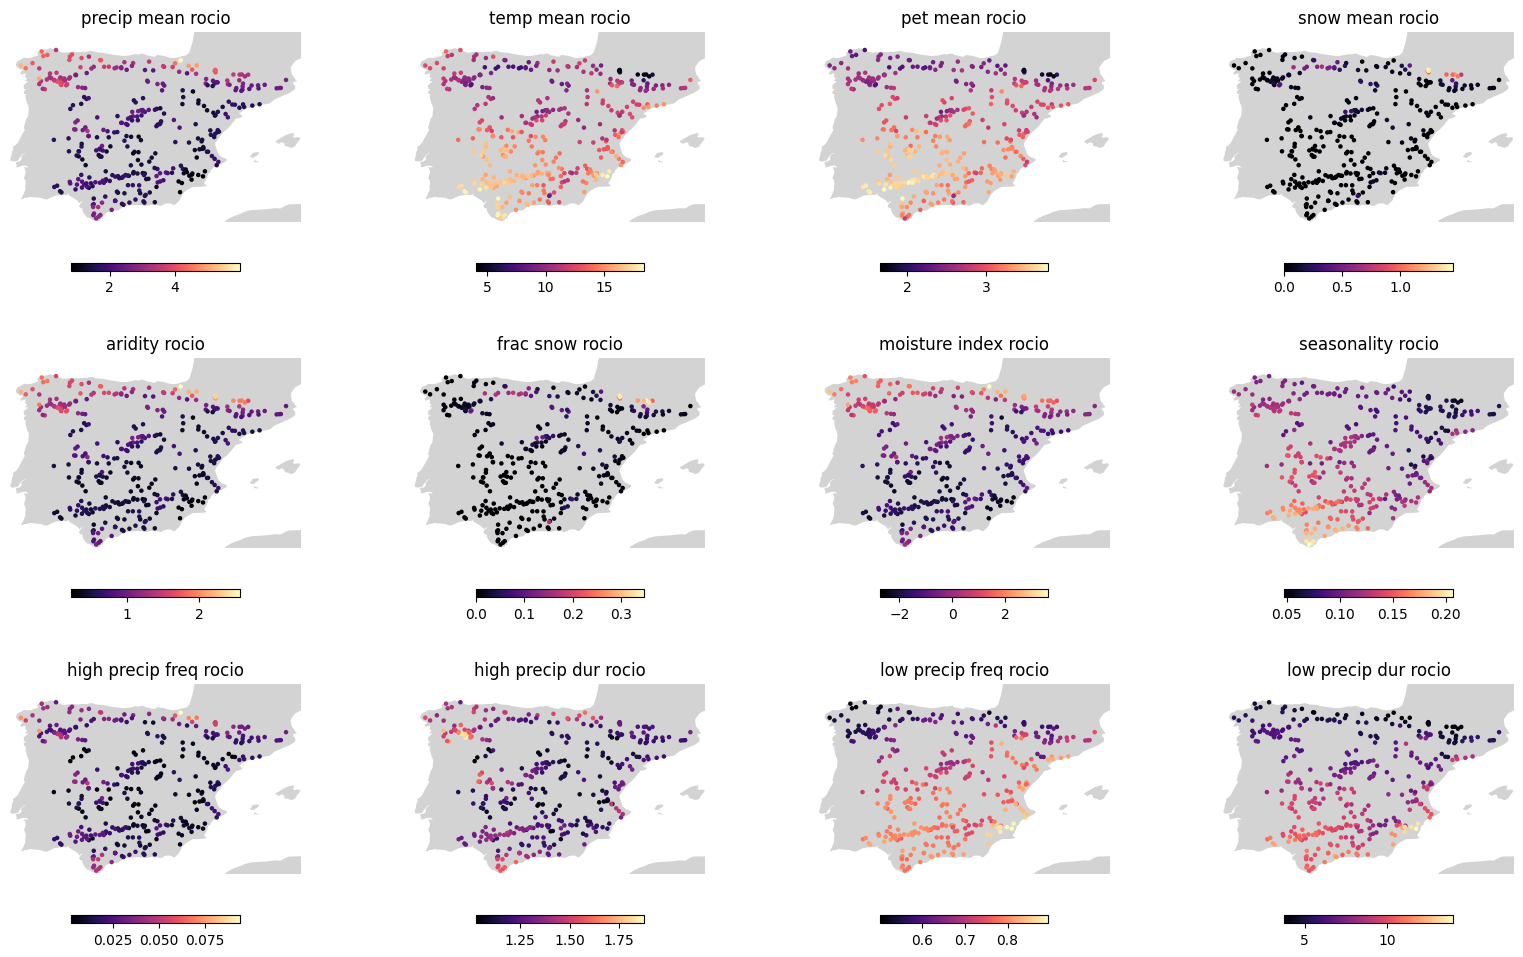

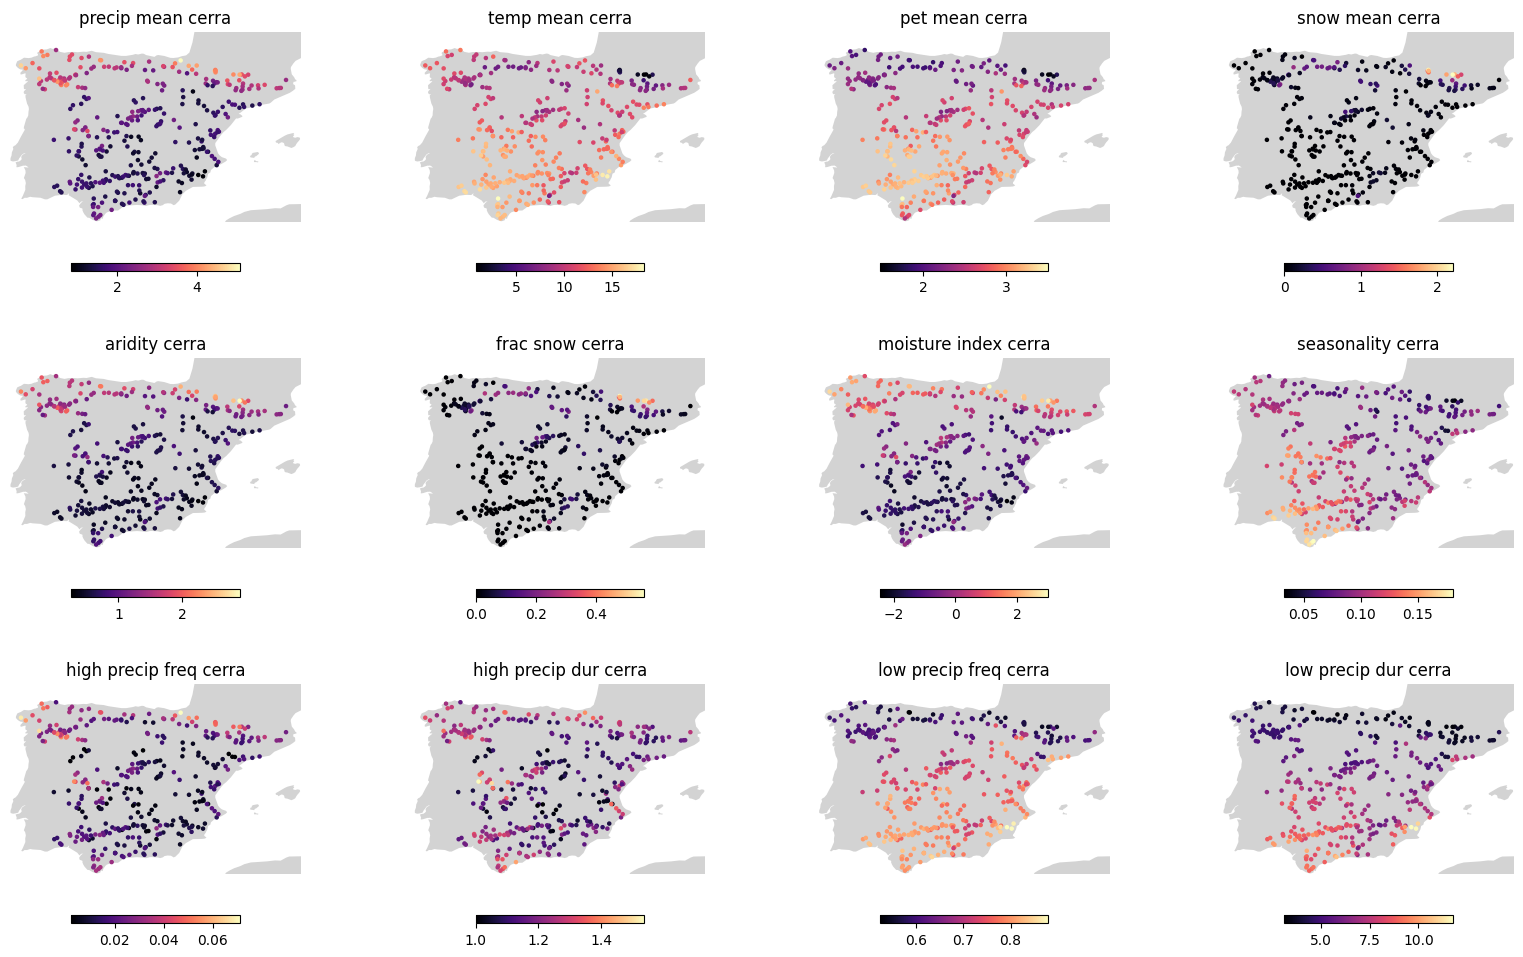

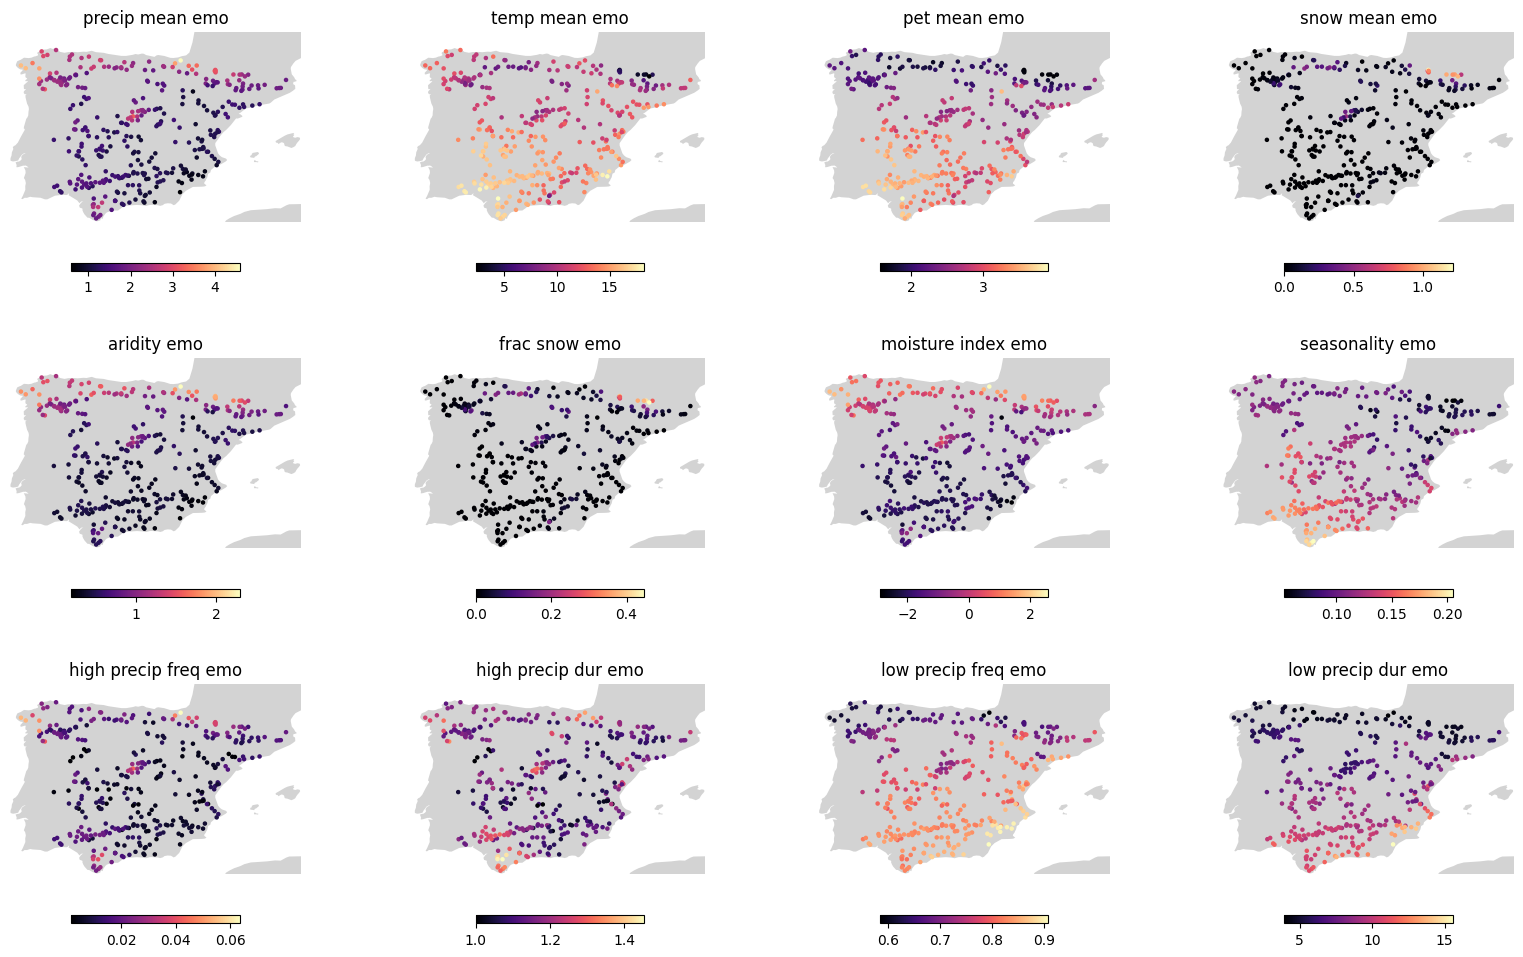

In [6]:
# plot attributes
r = 5
for label, attrs in attributes.items():
    plot_attributes(
        attrs,
        outlets.geometry.x,
        outlets.geometry.y,
        ncols=4,
        extent=[-9.5, 3.5, 36, 44.5],
        save=path_plots / f'maps_climate_{label}.jpg'
    )

### Export

In [7]:
for label, attrs in attributes.items():
    
    # set index and sort
    attrs.sort_index(axis=0, inplace=True)
    attrs.index = [f'{cfg.prefix}_{ID}' for ID in attrs.index]
    attrs.index.name = basin_id_field
    print('{0:<5} - {1} climate indices define the climatology of {2} catchments'.format(label.upper(), *attrs.shape[::-1]))

    # export
    attrs.to_csv(cfg.path_attributes / f'climate_indices_{label}.csv', float_format='%.6f')

ROCIO - 12 climate indices define the climatology of 366 catchments
CERRA - 12 climate indices define the climatology of 366 catchments
EMO   - 12 climate indices define the climatology of 366 catchments
